# TFM — Pipeline QSAR para Reposicionamiento en Fibrosis Quística

**Autor:** Vicente Valero Just

**Máster en Bioinformática y Bioestadística (UOC, 2025–2026)**

---

## Estructura

1. Configuración y librerías
2. Funciones reutilizables
3. Dataset 1 — ChEMBL
4. Dataset 2 — Papyrus
5. Dataset 3 — BindingDB
6. Fusión de las 3 bases de datos
7. Modelo 1 — Baseline solo con ChEMBL
8. Modelo 2 — QSAR con dataset fusionado (+ comparación de modelos)
9. Candidatos y controles de validación
10. Dominio de aplicabilidad (Tanimoto)
11. Predicción de pIC50 e integración con docking
12. Validación del modelo con los controles
13. Ranking final
14. Visualizaciones
15. Exportar resultados
16. Figura comparativa de los cuatro perfiles PLIP

---
## 1. Configuración y librerías

Si las dependencias ya están instaladas, la primera celda no hace nada.

In [45]:
# Instalación de dependencias (descomentar la primera vez)
# !pip install chembl-webresource-client papyrus-scripts rdkit scikit-learn pandas numpy matplotlib seaborn -q

In [46]:
# Manejo de datos
import pandas as pd
import numpy as np
import time
import os

# Visualización
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams['figure.dpi'] = 130

# Química computacional (RDKit)
from rdkit import Chem, DataStructs
from rdkit.Chem import Descriptors, Lipinski, AllChem, rdMolDescriptors

# Machine Learning (scikit-learn)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error

# Cliente ChEMBL
from chembl_webresource_client.new_client import new_client

# Semilla para reproducibilidad
SEED = 42
np.random.seed(SEED)

# Parámetros del fingerprint (los mismos en todo el notebook)
FP_SIZE = 1024
FP_RADIUS = 2

print("Librerías cargadas. SEED =", SEED)

Librerías cargadas. SEED = 42


---
## 2. Funciones

Las definimos una sola vez al principio para no repetir código. Las usan
todas las secciones siguientes.


### Ley de Lipinski (regla de los cinco):
Es una regla empírica que predice si un compuesto químico tiene probabilidades de ser un fármaco activo por vía oral. Se llama "de los cinco" porque los límites clave son múltiplos de 5:

- Peso molecular ≤ 500 Da

- Log P (lipofilicidad) ≤ 5

- Donadores de enlaces de H (grupos -OH, -NH) ≤ 5

- Aceptores de enlaces de H (átomos de N u O) ≤ 10

Si un compuesto viola más de uno de estos criterios, es probable que tenga mala absorción oral.


In [47]:
def cumple_lipinski(smiles):
    """True si el compuesto cumple la regla de Lipinski (drug-likeness)."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return False
        return (Descriptors.MolWt(mol) < 500 and
                Descriptors.MolLogP(mol) < 5 and
                Lipinski.NumHDonors(mol) <= 5 and
                Lipinski.NumHAcceptors(mol) <= 10)
    except Exception:
        return False


def smiles_canonico(smi):
    """SMILES canonicalizado por RDKit (clave para deduplicar). None si falla."""
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol) if mol is not None else None
    except Exception:
        return None


def calcular_features(smiles):
    """7 descriptores fisicoquímicos + Morgan fingerprint (1024 bits)."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        desc = np.array([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            Lipinski.NumHDonors(mol),
            Lipinski.NumHAcceptors(mol),
            rdMolDescriptors.CalcNumRotatableBonds(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol),
        ])
        gen = AllChem.GetMorganGenerator(radius=FP_RADIUS, fpSize=FP_SIZE)
        fp = np.array(gen.GetFingerprintAsNumPy(mol))
        return np.concatenate([desc, fp])
    except Exception:
        return None


def get_morgan_fp(smiles, n_bits=FP_SIZE, radius=FP_RADIUS):
    """Morgan fingerprint como bit-vector RDKit (para Tanimoto)."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    gen = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    return gen.GetFingerprint(mol)


def similitud_maxima_tanimoto(smiles_candidato, fps_referencia):
    """Tanimoto máximo de un candidato frente al conjunto de entrenamiento."""
    fp = get_morgan_fp(smiles_candidato)
    if fp is None:
        return None, 0
    sims = DataStructs.BulkTanimotoSimilarity(fp, fps_referencia)
    return max(sims), sum(1 for s in sims if s >= 0.40)


def clasificar_confianza(sim):
    """Nivel de confianza de la predicción según el Tanimoto máximo."""
    if sim is None:
        return 'Error'
    elif sim >= 0.40:
        return 'Alta (dentro del dominio)'
    elif sim >= 0.20:
        return 'Media (zona marginal)'
    else:
        return 'Baja (fuera del dominio)'


print("Funciones definidas: Lipinski, canonicalización, features, Tanimoto, AD")

Funciones definidas: Lipinski, canonicalización, features, Tanimoto, AD


---
## 3. Dataset 1 — ChEMBL

Descargamos las actividades de CFTR (CHEMBL4051) por API: IC50, Ki y EC50.

In [ ]:
# Se conecta a la base de datos de ChEMBL
activities = new_client.activity

# Lista con los nombres de los datos que nos interesan: identificador del compuesto, valor de actividad,
# unidades, estructura química y tipo de ensayo.
CAMPOS = ['molecule_chembl_id', 'standard_value', 'standard_units',
          'canonical_smiles', 'standard_type']

frames_chembl = []
# medidas biológicas (IC50, Ki, EC50) una por una
for tipo in ['IC50', 'Ki', 'EC50']:
    print(f"Descargando {tipo}...")
    intentos, exito = 0, False
    while intentos < 3 and not exito:
        try:
            datos = activities.filter(
                # Filtra los datos para que solo sean CHEMBL4051, de tipo humano (Homo sapiens) y 
                # con la medida actual (IC50, Ki o EC50).
                target_chembl_id='CHEMBL4051',
                standard_type=tipo,
                target_organism='Homo sapiens'
            ).only(CAMPOS)
            # Convierte los datos descargados en una tabla
            df_tipo = pd.DataFrame.from_records(datos)
            # Añade una columna que dice que esos datos vienen de ChEMBL
            df_tipo['fuente'] = 'ChEMBL'
            # Guarda esa tabla en una lista para después juntarlas todas
            frames_chembl.append(df_tipo)
            print(f"  -> {len(df_tipo)} registros")
            exito = True
        except Exception as e:
            intentos += 1
            print(f"  Error (intento {intentos}/3): {e}")
            if intentos < 3:
                time.sleep(10)

# Junta todas las tablas (IC50, Ki y EC50) en una sola.
df_chembl_raw = pd.concat(frames_chembl, ignore_index=True)
# Guarda la tabla final en un archivo llamado chembl_cftr_bruto.csv
df_chembl_raw.to_csv('chembl_cftr_bruto.csv', index=False)
print(f"\nChEMBL bruto: {len(df_chembl_raw)} registros (copia guardada)")

Descargando IC50...
  -> 159 registros
Descargando Ki...
  -> 4 registros
Descargando EC50...
  -> 1387 registros

ChEMBL bruto: 1550 registros (copia guardada)


**Limpieza de ChEMBL** — nulos, unidades nM, conversión a pIC50, Lipinski, actividad y deduplicación.

In [49]:
# Nulos y conversión numérica
df = df_chembl_raw.dropna(subset=['canonical_smiles', 'standard_value']).copy()
df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
df = df.dropna(subset=['standard_value'])

# Solo unidades nM
df = df[df['standard_units'] == 'nM'].copy()

# Conversión a pIC50  (limitamos valores extremos > 1e8 nM)
df['pIC50'] = -np.log10(df['standard_value'].clip(upper=1e8) * 1e-9)

# Lipinski + actividad (pIC50 >= 5)
df['lipinski_ok'] = df['canonical_smiles'].apply(cumple_lipinski)
df = df[df['lipinski_ok'] & (df['pIC50'] >= 5)].copy()

# Deduplicar: mayor pIC50 por compuesto
df = df.sort_values('pIC50', ascending=False)
df_chembl = (df.drop_duplicates(subset='molecule_chembl_id', keep='first')
               [['canonical_smiles', 'pIC50']]
               .reset_index(drop=True))
df_chembl['fuente'] = 'ChEMBL'

print(f"ChEMBL limpio: {len(df_chembl)} compuestos únicos")
print(f"pIC50: {df_chembl['pIC50'].min():.2f} - {df_chembl['pIC50'].max():.2f}"
      f"  (media {df_chembl['pIC50'].mean():.2f})")

ChEMBL limpio: 513 compuestos únicos
pIC50: 5.00 - 9.51  (media 6.38)


---
## 4. Dataset 2 — Papyrus

Papyrus es una base de datos de bioactividad de alta calidad. Descargamos la
versión 05.7 y filtramos por CFTR (UniProt P13569).

**Aviso:** la primera descarga ocupa varios GB y tarda. Después queda en caché.

In [50]:
from papyrus_scripts.download import download_papyrus
from papyrus_scripts.reader import read_papyrus
from papyrus_scripts.utils.IO import get_downloaded_versions

# Descargar solo si no está en caché
if '05.7' not in get_downloaded_versions():
    print("Descargando Papyrus 05.7 (varios minutos)...")
    download_papyrus(version='05.7', only_pp=False)

# Leer por bloques y filtrar CFTR
papyrus_data = read_papyrus(version='05.7', plusplus=False, chunksize=100000)

UNIPROT_CFTR = 'P13569'
bloques = [chunk[chunk['accession'] == UNIPROT_CFTR]
           for chunk in papyrus_data]
bloques = [b for b in bloques if len(b) > 0]

df_papyrus_raw = pd.concat(bloques, ignore_index=True) if bloques else pd.DataFrame()
print(f"Papyrus CFTR bruto: {len(df_papyrus_raw)} registros")

C:\Users\Vincenzo Just\AppData\Local\Temp\ipykernel_38272\443604891.py:15: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in papyrus_data]


Papyrus CFTR bruto: 371193 registros


**Limpieza de Papyrus** — calidad alta, renombrado de columnas, Lipinski,
actividad y deduplicación por mediana de pIC50.

In [ ]:
# Se queda solo con los datos de alta calidad (la columna 'Quality' dice 'High')
df_p = df_papyrus_raw[df_papyrus_raw['Quality'] == 'High'].copy()
# Cambia el nombre de algunas columnas para que se llamen igual
df_p = df_p.rename(columns={
    'SMILES': 'canonical_smiles',
    'pchembl_value_Mean': 'pIC50',
    'connectivity': 'molecule_id',
})

# Aplica una función llamada cumple_lipinski a cada SMILES
df_p['lipinski_ok'] = df_p['canonical_smiles'].apply(cumple_lipinski)
# Filtra para quedarse solo con los compuestos que Cumplen Lipinski y tienen una pIC50 mayor o igual a 5 
df_p = df_p[df_p['lipinski_ok'] & (df_p['pIC50'] >= 5)].copy()

df_papyrus = (df_p.groupby('molecule_id')
                  .agg({'canonical_smiles': 'first', 'pIC50': 'median'})
                  .reset_index()[['canonical_smiles', 'pIC50']])
# Añade una columna que dice que estos datos vienen de la base de datos Papyrus.
df_papyrus['fuente'] = 'Papyrus'

print(f"Papyrus limpio: {len(df_papyrus)} compuestos únicos")

Papyrus limpio: 789 compuestos únicos


---
## 5. Dataset 3 — BindingDB

BindingDB **no tiene API**: el archivo TSV se descarga manualmente desde su web
(búsqueda por target CFTR) y se coloca en la carpeta del notebook.

In [52]:
# Ruta del TSV de BindingDB descargado manualmente
RUTA_BINDINGDB = 'bindingdb_cftr.tsv'

if os.path.exists(RUTA_BINDINGDB):
    df_bdb_raw = pd.read_csv(RUTA_BINDINGDB, sep='\t',
                             on_bad_lines='skip', low_memory=False)
    print(f"BindingDB bruto: {len(df_bdb_raw)} registros")
    USAR_BINDINGDB = True
else:
    print(f"[Aviso] No se encuentra '{RUTA_BINDINGDB}'.")
    print("El notebook continuará solo con ChEMBL + Papyrus.")
    df_bdb_raw = pd.DataFrame()
    USAR_BINDINGDB = False

BindingDB bruto: 1749 registros


**Limpieza de BindingDB** — cálculo de pIC50 (prioridad IC50 > Ki > Kd >
EC50), Lipinski, actividad y deduplicación.

In [ ]:
# Convierte a número decimal y si da error (porque no es número), devuelve NaN
def limpiar_valor_nM(v):
    try:
        return float(str(v).replace('<', '').replace('>', '').strip())
    except Exception:
        return np.nan

# Mira varias columnas, Toma el primer valor que sea un número positivo y  convierte nM (nanomolar) a pIC50
def pIC50_bindingdb(row):
    for col in ['IC50 (nM)', 'Ki (nM)', 'Kd (nM)', 'EC50 (nM)']:
        v = limpiar_valor_nM(row.get(col, np.nan))
        if not np.isnan(v) and v > 0:
            return -np.log10(v * 1e-9)
    return np.nan


if USAR_BINDINGDB:
    # Añade una columna pIC50 calculada con la función anterior para cada fila.
    df_bdb_raw['pIC50'] = df_bdb_raw.apply(pIC50_bindingdb, axis=1)
    # Elimina filas que no tengan SMILES (estructura química) o pIC50
    df_b = df_bdb_raw.dropna(subset=['Ligand SMILES', 'pIC50']).copy()
    # Cambia el nombre de esa columna para que se llame igual que en otras tablas.
    df_b = df_b.rename(columns={'Ligand SMILES': 'canonical_smiles'})
    # Se queda solo con compuestos potentes (pIC50 ≥ 5).
    df_b = df_b[df_b['pIC50'] >= 5].copy()

    # Aplica la regla de Lipinski a cada SMILES
    df_b['lipinski_ok'] = df_b['canonical_smiles'].apply(cumple_lipinski)
    # Filtra para dejar solo los que cumplen Lipinski.
    df_b = df_b[df_b['lipinski_ok']].copy()

    # Convierte cada SMILES a una forma única y ordenada
    df_b['canonical_key'] = df_b['canonical_smiles'].apply(smiles_canonico)
    # Borra los que no se pudieron convertir
    df_b = df_b.dropna(subset=['canonical_key'])

    df_bindingdb = (df_b.groupby('canonical_key')
                        .agg({'canonical_smiles': 'first', 'pIC50': 'median'})
                        .reset_index()[['canonical_smiles', 'pIC50']])
    df_bindingdb['fuente'] = 'BindingDB'
    print(f"BindingDB limpio: {len(df_bindingdb)} compuestos únicos")
else:
    # Crea una tabla vacía con las mismas columnas y avisa que se omitió
    df_bindingdb = pd.DataFrame(columns=['canonical_smiles', 'pIC50', 'fuente'])
    print("BindingDB omitido.")

BindingDB limpio: 475 compuestos únicos


---
## 6. Fusión de las 3 bases de datos

Unimos las tres fuentes. Generamos una clave canónica (SMILES canonicalizado)
y, si un compuesto aparece en varias bases, nos quedamos con la **mediana** de
su pIC50. Este es el dataset con el que se entrena el modelo.

In [54]:
# Unir las tres fuentes
df_all = pd.concat([df_chembl, df_papyrus, df_bindingdb], ignore_index=True)

# Clave canónica para deduplicar
df_all['canonical_key'] = df_all['canonical_smiles'].apply(smiles_canonico)
df_all = df_all.dropna(subset=['canonical_key'])

# Deduplicar: mediana de pIC50 + lista de fuentes
df_dataset = (df_all.groupby('canonical_key')
                    .agg({'canonical_smiles': 'first',
                          'pIC50': 'median',
                          'fuente': lambda x: ','.join(sorted(set(x)))})
                    .reset_index())

df_dataset.to_csv('dataset_completo.csv', index=False)

print(f"DATASET COMPLETO: {len(df_dataset)} compuestos únicos")
print(f"pIC50: {df_dataset['pIC50'].min():.2f} - {df_dataset['pIC50'].max():.2f}"
      f"  (media {df_dataset['pIC50'].mean():.2f})")
print("\nCompuestos por combinación de fuentes:")
print(df_dataset['fuente'].value_counts())
print("\nGuardado: dataset_completo.csv")

DATASET COMPLETO: 1082 compuestos únicos
pIC50: 5.00 - 9.51  (media 5.98)

Compuestos por combinación de fuentes:
fuente
Papyrus                     530
BindingDB,ChEMBL,Papyrus    243
BindingDB,ChEMBL            193
ChEMBL                       62
BindingDB                    38
ChEMBL,Papyrus               15
BindingDB,Papyrus             1
Name: count, dtype: int64

Guardado: dataset_completo.csv


---
## 7. Modelo 1 — Baseline solo con ChEMBL

Antes de entrenar el modelo con las tres bases fusionadas, entrenamos un
**modelo baseline solo con ChEMBL** para poder comparar el impacto de añadir
Papyrus y BindingDB al dataset.

**Objetivo de la comparación:** comprobar si fusionar las tres fuentes mejora
la capacidad predictiva del modelo respecto a usar solo ChEMBL.

**Limitación metodológica:** los dos modelos se entrenan con datasets de
tamaño y composición distinta, por lo que el R² y RMSE no son estrictamente
comparables en términos absolutos. La comparación es orientativa.

In [ ]:
# Modelo 1 — Baseline solo con ChEMBL
print("Calculando features del dataset ChEMBL...")
X_list_c = df_chembl['canonical_smiles'].apply(calcular_features)
valid_c = X_list_c.notna()
X_chembl = np.array(X_list_c[valid_c].tolist())
y_chembl = df_chembl['pIC50'][valid_c].values
print(f"Features calculadas: {X_chembl.shape[0]} compuestos, {X_chembl.shape[1]} features")

# Mismos hiperparámetros que el modelo fusionado para que la comparación sea justa
rf_chembl = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_leaf=2,
    random_state=SEED, n_jobs=-1
)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Validación cruzada (5-fold)
r2_cv_c = cross_val_score(rf_chembl, X_chembl, y_chembl, cv=cv, scoring='r2')
rmse_cv_c = np.sqrt(-cross_val_score(rf_chembl, X_chembl, y_chembl, cv=cv,
                                     scoring='neg_mean_squared_error'))
print(f"\n[Solo ChEMBL] R² CV:   {r2_cv_c.mean():.3f} ± {r2_cv_c.std():.3f}")
print(f"[Solo ChEMBL] RMSE CV: {rmse_cv_c.mean():.3f} ± {rmse_cv_c.std():.3f}")

# Hold-out 20%
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_chembl, y_chembl, test_size=0.20, random_state=SEED
)
rf_chembl.fit(X_tr_c, y_tr_c)
y_pred_c = rf_chembl.predict(X_te_c)
r2_ho_c = r2_score(y_te_c, y_pred_c)
rmse_ho_c = np.sqrt(mean_squared_error(y_te_c, y_pred_c))
print(f"[Solo ChEMBL] R² hold-out:   {r2_ho_c:.3f}")
print(f"[Solo ChEMBL] RMSE hold-out: {rmse_ho_c:.3f}")

# Guardamos las métricas para la tabla comparativa
metricas_chembl = {
    'n_compuestos': len(y_chembl),
    'r2_cv': r2_cv_c.mean(), 'r2_cv_std': r2_cv_c.std(),
    'rmse_cv': rmse_cv_c.mean(), 'rmse_cv_std': rmse_cv_c.std(),
    'r2_ho': r2_ho_c, 'rmse_ho': rmse_ho_c,
}

Calculando features del dataset ChEMBL...
Features calculadas: 513 compuestos, 1031 features

[Solo ChEMBL] R² CV:   0.544 ± 0.172
[Solo ChEMBL] RMSE CV: 0.679 ± 0.074
[Solo ChEMBL] R² hold-out:   0.729
[Solo ChEMBL] RMSE hold-out: 0.578


---
## 8. Modelo 2 — QSAR con dataset fusionado (ChEMBL + Papyrus + BindingDB)

Calculamos las features del dataset fusionado y entrenamos un Random Forest
con los mismos hiperparámetros que el Modelo 1, para que la comparación sea justa.

Para la evaluación usamos **dos métodos complementarios**:
- **Validación cruzada (5-fold)**: estima el rendimiento promedio sobre todo el dataset.
- **Hold-out (20%)**: una partición fija que el modelo no ve durante el entrenamiento,
  para obtener un valor independiente.

Tras la evaluación, el modelo final se reentrena con el 100% de los datos —
**este Modelo 2 fusionado es el que se usa para predecir los candidatos**.

In [ ]:
print("Calculando features del dataset completo...")
# Para cada SMILES (estructura química) de la tabla df_dataset y aplica calcular_features.
X_list = df_dataset['canonical_smiles'].apply(calcular_features)
#  Indica compuestos sí dieron features válidos
valid = X_list.notna()
# De la lista X_list, se queda solo con los que son válidos
X = np.array(X_list[valid].tolist())
# Toma la columna pIC50 (potencia de cada compuesto) pero solo para las filas válidas, y la convierte en un array
y = df_dataset['pIC50'][valid].values
print(f"Compuestos válidos: {len(y)}  |  dimensiones X: {X.shape}")

Calculando features del dataset completo...
Compuestos válidos: 1082  |  dimensiones X: (1082, 1031)


**Hiperparámetros.** Mantenemos `n_estimators=200` y `min_samples_leaf=2`
(200 árboles dan estabilidad sin coste
excesivo, y exigir 2 muestras por hoja reduce el sobreajuste). Un valor mayor
de árboles apenas cambia el resultado.

---

## validación cruzada k=5 sobre todo el dataset → R² = 0,649.

In [ ]:
# Modelo y esquema de validación
rf = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_leaf=2,
    random_state=SEED, n_jobs=-1
)
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Validación cruzada
r2_cv = cross_val_score(rf, X, y, cv=cv, scoring='r2')
rmse_cv = np.sqrt(-cross_val_score(rf, X, y, cv=cv,
                                   scoring='neg_mean_squared_error'))
print("Validación cruzada (k=5):")
print(f"  R2   = {r2_cv.mean():.3f} +/- {r2_cv.std():.3f}")
print(f"  RMSE = {rmse_cv.mean():.3f} +/- {rmse_cv.std():.3f}")

Validación cruzada (k=5):
  R2   = 0.649 +/- 0.040
  RMSE = 0.514 +/- 0.032


---

## hold-out: entrena con 80%, mide sobre el 20% no visto → R² = 0,686.


In [ ]:
# Hold-out test (20% que el modelo no ve al entrenar)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)

print("Hold-out test (20%):")
print(f"  R2   = {r2_score(y_te, y_pred):.3f}")
print(f"  RMSE = {np.sqrt(mean_squared_error(y_te, y_pred)):.3f}")
print("\nSi el R2 del hold-out es parecido al de CV, no hay sobreajuste grave.")

Hold-out test (20%):
  R2   = 0.686
  RMSE = 0.465

Si el R2 del hold-out es parecido al de CV, no hay sobreajuste grave.


In [59]:
# Guardamos métricas del modelo fusionado para la comparación
metricas_fusion = {
    'n_compuestos': len(y),
    'r2_cv': r2_cv.mean(), 'r2_cv_std': r2_cv.std(),
    'rmse_cv': rmse_cv.mean(), 'rmse_cv_std': rmse_cv.std(),
    'r2_ho': r2_score(y_te, y_pred), 'rmse_ho': np.sqrt(mean_squared_error(y_te, y_pred)),
}

**Modelo final.** Lo reentrenamos con el 100% de los datos. Este es el
modelo que se usa para predecir los candidatos.

In [60]:
rf.fit(X, y)
print("Modelo final entrenado con los", len(y), "compuestos del dataset completo.")

# Fingerprints del dataset completo (para el dominio de aplicabilidad)
print("Calculando fingerprints para el dominio de aplicabilidad...")
fps_train = [fp for fp in
             (get_morgan_fp(s) for s in df_dataset['canonical_smiles'])
             if fp is not None]
print(f"Fingerprints de referencia: {len(fps_train)}")

Modelo final entrenado con los 1082 compuestos del dataset completo.
Calculando fingerprints para el dominio de aplicabilidad...
Fingerprints de referencia: 1082


---
### Comparación: Modelo 1 (ChEMBL) vs Modelo 2 (Fusionado)

Resumen del rendimiento de ambos modelos.

In [61]:
# Tabla comparativa
tabla_comp = pd.DataFrame({
    'Modelo': ['Modelo 1 — Solo ChEMBL', 'Modelo 2 — ChEMBL+Papyrus+BindingDB'],
    'N compuestos': [metricas_chembl['n_compuestos'], metricas_fusion['n_compuestos']],
    'R² (CV 5-fold)': [f"{metricas_chembl['r2_cv']:.3f} ± {metricas_chembl['r2_cv_std']:.3f}",
                       f"{metricas_fusion['r2_cv']:.3f} ± {metricas_fusion['r2_cv_std']:.3f}"],
    'RMSE (CV 5-fold)': [f"{metricas_chembl['rmse_cv']:.3f} ± {metricas_chembl['rmse_cv_std']:.3f}",
                         f"{metricas_fusion['rmse_cv']:.3f} ± {metricas_fusion['rmse_cv_std']:.3f}"],
    'R² (hold-out 20%)': [f"{metricas_chembl['r2_ho']:.3f}",
                          f"{metricas_fusion['r2_ho']:.3f}"],
    'RMSE (hold-out 20%)': [f"{metricas_chembl['rmse_ho']:.3f}",
                            f"{metricas_fusion['rmse_ho']:.3f}"],
})
print(tabla_comp.to_string(index=False))
tabla_comp.to_csv('comparacion_modelos.csv', index=False)

                             Modelo  N compuestos R² (CV 5-fold) RMSE (CV 5-fold) R² (hold-out 20%) RMSE (hold-out 20%)
             Modelo 1 — Solo ChEMBL           513  0.544 ± 0.172    0.679 ± 0.074             0.729               0.578
Modelo 2 — ChEMBL+Papyrus+BindingDB          1082  0.649 ± 0.040    0.514 ± 0.032             0.686               0.465


---
## 9. Candidatos y controles de validación

Definimos cuatro grupos de moléculas:

- **7 candidatos** — identificados a partir del análisis de redes PPI (STRING)
  y DrugBank. Son los que se evalúan y se rankean.
- **Controles positivos** — Ivacaftor y los correctores aprobados para CFTR
  (Lumacaftor, Tezacaftor, Elexacaftor). Sirven de **techo de referencia**: el
  modelo debería darles un pIC50 alto.
- **Controles negativos** — fármacos sin interacción conocida con CFTR
  (Paracetamol, Aspirina, Metformina). Sirven de **baseline**: el modelo
  debería darles un pIC50 bajo.
- **R406** — metabolito activo de Fostamatinib (que es un profármaco).

Importante: **los controles NO entran en el ranking**. Se usan solo para
validar el modelo y el docking. El ranking de la sección 12 contiene solo los
7 candidatos.

In [62]:
# --- 7 candidatos + Ivacaftor ---
candidatos = [
    # (nombre, hub_diana, SMILES, DrugBank ID, indicación, grupo)
    ('Bumetanide',       'CFTR',     'CCCCNC1=C(OC2=CC=CC=C2)C(=CC(=C1)C(O)=O)S(N)(=O)=O',
                                     'DB00887', 'Diurético',      'Candidato'),
    ('Glyburide',        'CFTR',     'COC1=C(C=C(Cl)C=C1)C(=O)NCCC1=CC=C(C=C1)S(=O)(=O)NC(=O)NC1CCCCC1',
                                     'DB01016', 'Antidiabético',  'Candidato'),
    ('Ibuprofen',        'CFTR',     'CC(C)CC1=CC=C(C=C1)C(C)C(O)=O',
                                     'DB01050', 'AINE',           'Candidato'),
    ('Cromoglicic_acid', 'HSP90AA1', 'OC(COC1=CC=CC2=C1C(=O)C=C(O2)C(O)=O)COC1=CC=CC2=C1C(=O)C=C(O2)C(O)=O',
                                     'DB01003', 'Antialérgico',   'Candidato'),
    ('Fostamatinib',     'PRKACA',   'COC1=CC(NC2=NC=C(F)C(NC3=NC4=C(OC(C)(C)C(=O)N4COP(O)(O)=O)C=C3)=N2)=CC(OC)=C1OC',
                                     'DB12010', 'Inmunomodulador','Candidato'),
    ('Dasatinib',        'HSPA8',    'CC1=NC(NC2=NC=C(S2)C(=O)NC2=C(C)C=CC=C2Cl)=CC(=N1)N1CCN(CCO)CC1',
                                     'DB01254', 'Antineoplásico', 'Candidato'),
    ('Artenimol',        'HSPA8',    '[H][C@@]12CC[C@@H](C)[C@]3([H])CC[C@@]4(C)OO[C@@]13[C@]([H])(O[C@H](O)[C@@H]2C)O4',
                                     'DB11638', 'Antimalárico',   'Candidato'),
    ('Ivacaftor',        'CFTR',     'CC(C)(C)C1=CC(=C(O)C=C1NC(=O)C1=CNC2=CC=CC=C2C1=O)C(C)(C)C',
                                     'DB08820', 'FQ - modulador', 'Control (+)'),
]

# --- Controles positivos adicionales: correctores aprobados ---
controles_pos = [
    ('Lumacaftor',  'CFTR', 'CC1=CC=C(NC(=O)C2(CC2)C2=CC=C3OC(F)(F)OC3=C2)N=C1C1=CC(=CC=C1)C(O)=O',
                            'DB09280', 'FQ - corrector', 'Control (+)'),
    ('Tezacaftor',  'CFTR', 'CC(C)(CO)C1=CC2=CC(NC(=O)C3(CC3)C3=CC=C4OC(F)(F)OC4=C3)=C(F)C=C2N1C[C@@H](O)CO',
                            'DB11712', 'FQ - corrector', 'Control (+)'),
    ('Elexacaftor', 'CFTR', 'C[C@@H]1CN(C2=NC(=CC=C2C(=O)NS(=O)(=O)C2=CN(C)N=C2C)N2C=CC(OCC(C)(C)C(F)(F)F)=N2)C(C)(C)C1',
                            'DB15444', 'FQ - corrector', 'Control (+)'),
]

# --- Controles negativos: sin interacción conocida con CFTR ---
controles_neg = [
    ('Paracetamol', 'Ninguna', 'CC(=O)NC1=CC=C(O)C=C1',
                               'DB00316', 'Control negativo', 'Control (-)'),
    ('Aspirina',    'Ninguna', 'CC(=O)OC1=CC=CC=C1C(O)=O',
                               'DB00945', 'Control negativo', 'Control (-)'),
    ('Metformina',  'Ninguna', 'CN(C)C(=N)NC(N)=N',
                               'DB00331', 'Control negativo', 'Control (-)'),
]

# --- R406: metabolito activo de Fostamatinib ---
r406 = [
    ('R406', 'PRKACA', 'COc1cc(Nc2ncc(F)c(Nc3ccc4c(n3)NC(=O)C(C)(C)O4)n2)cc(OC)c1OC',
                       'N/A', 'Metabolito activo', 'Metabolito'),
]

cols = ['nombre', 'hub_diana', 'smiles', 'drugbank_id', 'indicacion', 'grupo']

# Tabla única con todas las moléculas (candidatos + controles)
df_mol = pd.DataFrame(candidatos + controles_pos + controles_neg + r406,
                      columns=cols)

print("Moléculas definidas:")
print(df_mol['grupo'].value_counts())
df_mol[['nombre', 'grupo', 'hub_diana', 'indicacion']]

Moléculas definidas:
grupo
Candidato      7
Control (+)    4
Control (-)    3
Metabolito     1
Name: count, dtype: int64


,nombre,grupo,hub_diana,indicacion
0,Bumetanide,Candidato,CFTR,Diurético
1,Glyburide,Candidato,CFTR,Antidiabético
2,Ibuprofen,Candidato,CFTR,AINE
3,Cromoglicic_acid,Candidato,HSP90AA1,Antialérgico
4,Fostamatinib,Candidato,PRKACA,Inmunomodulador
5,Dasatinib,Candidato,HSPA8,Antineoplásico
6,Artenimol,Candidato,HSPA8,Antimalárico
7,Ivacaftor,Control (+),CFTR,FQ - modulador
8,Lumacaftor,Control (+),CFTR,FQ - corrector
9,Tezacaftor,Control (+),CFTR,FQ - corrector


---
## 10. Dominio de aplicabilidad (Tanimoto)

Calculamos la similitud Tanimoto máxima de **cada molécula** (candidatos y
controles) frente al **dataset completo**. Reutilizamos los fingerprints
`fps_train` calculados en la sección 7. Un Tanimoto alto significa que el
modelo ha visto moléculas parecidas y su predicción es más fiable.

In [63]:
ad = df_mol['smiles'].apply(lambda s: similitud_maxima_tanimoto(s, fps_train))
df_mol['tanimoto_max'] = [round(t[0], 3) if t[0] else None for t in ad]
df_mol['confianza_prediccion'] = df_mol['tanimoto_max'].apply(clasificar_confianza)

print("Dominio de aplicabilidad (frente al dataset completo):\n")
print(df_mol[['nombre', 'grupo', 'tanimoto_max', 'confianza_prediccion']]
      .to_string(index=False))

Dominio de aplicabilidad (frente al dataset completo):

          nombre       grupo  tanimoto_max      confianza_prediccion
      Bumetanide   Candidato         0.270     Media (zona marginal)
       Glyburide   Candidato         0.333     Media (zona marginal)
       Ibuprofen   Candidato         0.312     Media (zona marginal)
Cromoglicic_acid   Candidato         0.233     Media (zona marginal)
    Fostamatinib   Candidato         0.229     Media (zona marginal)
       Dasatinib   Candidato         0.272     Media (zona marginal)
       Artenimol   Candidato         0.298     Media (zona marginal)
       Ivacaftor Control (+)         0.880 Alta (dentro del dominio)
      Lumacaftor Control (+)         1.000 Alta (dentro del dominio)
      Tezacaftor Control (+)         0.730 Alta (dentro del dominio)
     Elexacaftor Control (+)         0.576 Alta (dentro del dominio)
     Paracetamol Control (-)         0.341     Media (zona marginal)
        Aspirina Control (-)         0.435 Alta

---
## 11. Predicción de pIC50 e integración con docking

Predecimos el pIC50 de **todas las moléculas** con el modelo completo (sección
7) y añadimos las energías de docking calculadas con AutoDock Vina.

In [64]:
# Predicción de pIC50 con el modelo completo (todas las moléculas)
feats = df_mol['smiles'].apply(calcular_features)
X_mol = np.array(feats.tolist())
df_mol['pIC50_pred'] = rf.predict(X_mol)

# Energías de docking (AutoDock Vina)
docking_wt = {
    'Bumetanide': -7.210, 'Glyburide': -10.105, 'Ibuprofen': -6.593,
    'Cromoglicic_acid': -9.347, 'Fostamatinib': -9.009, 'Dasatinib': -9.131,
    'Artenimol': -6.613, 'Ivacaftor': -9.493,
    'Lumacaftor': -10.775, 'Tezacaftor': -10.213, 'Elexacaftor': -9.493,
    'Paracetamol': -6.164, 'Aspirina': -5.701, 'Metformina': -5.268,
    'R406': -9.177,
}
docking_delta = {
    'Bumetanide': -7.147, 'Glyburide': -9.684, 'Ibuprofen': -6.267,
    'Cromoglicic_acid': -9.326, 'Fostamatinib': -8.781, 'Dasatinib': -9.242,
    'Artenimol': -6.886, 'Ivacaftor': -9.651,
    'Lumacaftor': -10.293, 'Tezacaftor': -10.168, 'Elexacaftor': -9.379,
    'Paracetamol': -5.608, 'Aspirina': -5.432, 'Metformina': -5.798,
    'R406': -9.301,
}
df_mol['dock_wt'] = df_mol['nombre'].map(docking_wt)
df_mol['dock_delta'] = df_mol['nombre'].map(docking_delta)
df_mol['dock_media'] = (df_mol['dock_wt'] + df_mol['dock_delta']) / 2

print(df_mol[['nombre', 'grupo', 'pIC50_pred', 'tanimoto_max',
              'dock_media']].round(3).to_string(index=False))

          nombre       grupo  pIC50_pred  tanimoto_max  dock_media
      Bumetanide   Candidato       5.906         0.270      -7.178
       Glyburide   Candidato       5.768         0.333      -9.894
       Ibuprofen   Candidato       5.489         0.312      -6.430
Cromoglicic_acid   Candidato       6.390         0.233      -9.336
    Fostamatinib   Candidato       5.746         0.229      -8.895
       Dasatinib   Candidato       5.508         0.272      -9.186
       Artenimol   Candidato       5.793         0.298      -6.750
       Ivacaftor Control (+)       7.532         0.880      -9.572
      Lumacaftor Control (+)       5.618         1.000     -10.534
      Tezacaftor Control (+)       6.260         0.730     -10.190
     Elexacaftor Control (+)       6.714         0.576      -9.436
     Paracetamol Control (-)       5.723         0.341      -5.886
        Aspirina Control (-)       5.726         0.435      -5.566
      Metformina Control (-)       5.731         0.163      -5

---
## 12. Validación del modelo con los controles

Antes de fiarnos del ranking, comprobamos que el modelo se comporta de forma
coherente con los controles:

- Los **controles positivos** (moduladores/correctores aprobados) deberían
  recibir un pIC50 predicho **alto** y una energía de docking **baja** (buena
  unión).
- Los **controles negativos** deberían recibir un pIC50 **bajo** y un docking
  **alto** (unión débil) — marcan el baseline de energía inespecífica.
- **R406** debería puntuar al menos tan bien como Fostamatinib (su profármaco).

Si esto se cumple, el modelo distingue bien activos de inactivos y el ranking
de candidatos es más creíble.

In [65]:
# Resumen por grupo
resumen = (df_mol.groupby('grupo')
           .agg(n=('nombre', 'count'),
                pIC50_medio=('pIC50_pred', 'mean'),
                dock_medio=('dock_media', 'mean'))
           .round(3))
print("Resumen por grupo:\n")
print(resumen.to_string())

baseline_neg = df_mol.loc[df_mol['grupo'] == 'Control (-)', 'dock_media'].mean()
print(f"\nBaseline de docking (controles negativos): {baseline_neg:.3f} kcal/mol")

# Comprobaciones automáticas
pos = df_mol[df_mol['grupo'] == 'Control (+)']
neg = df_mol[df_mol['grupo'] == 'Control (-)']
ok_pic50 = pos['pIC50_pred'].mean() > neg['pIC50_pred'].mean()
ok_dock = pos['dock_media'].mean() < neg['dock_media'].mean()
print("\nComprobaciones:")
print(f"  pIC50 control(+) > control(-) : {'OK' if ok_pic50 else 'REVISAR'}")
print(f"  docking control(+) mejor que control(-) : {'OK' if ok_dock else 'REVISAR'}")

# R406 vs Fostamatinib
r406_d = df_mol.loc[df_mol['nombre'] == 'R406', 'dock_media'].iloc[0]
fosta_d = df_mol.loc[df_mol['nombre'] == 'Fostamatinib', 'dock_media'].iloc[0]
print(f"\nR406 docking = {r406_d:.3f}  vs  Fostamatinib = {fosta_d:.3f} kcal/mol")

Resumen por grupo:

             n  pIC50_medio  dock_medio
grupo                                  
Candidato    7        5.800      -8.239
Control (+)  4        6.531      -9.933
Control (-)  3        5.727      -5.662
Metabolito   1        5.568      -9.239

Baseline de docking (controles negativos): -5.662 kcal/mol

Comprobaciones:
  pIC50 control(+) > control(-) : OK
  docking control(+) mejor que control(-) : OK

R406 docking = -9.239  vs  Fostamatinib = -8.895 kcal/mol


**Gráfico de validación** — pIC50 predicho vs docking, coloreado por
grupo. Los controles positivos deben quedar arriba-izquierda (mejor) y los
negativos abajo-derecha (peor).

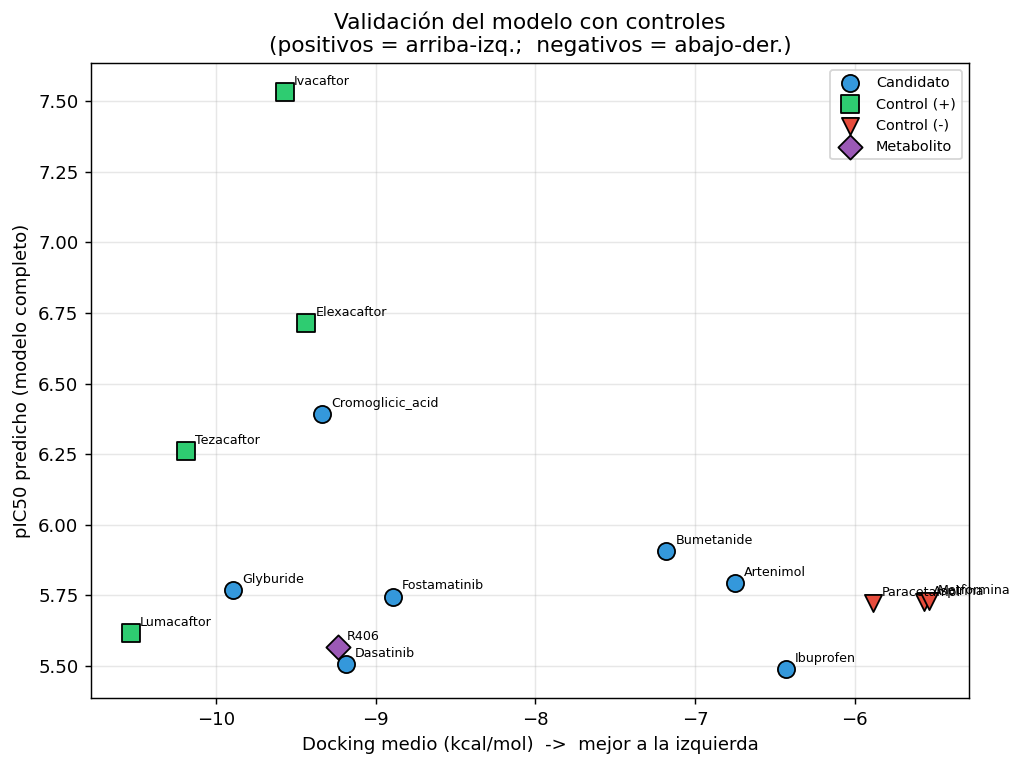

Guardado: fig_validacion_controles.png


In [ ]:
# Crea una figura
fig, ax = plt.subplots(figsize=(8, 6))


# Candidato → color azul, círculo
# Control (+) → verde, cuadrado
# Control (-) → rojo, triángulo invertido
# Metabolito → morado, rombo
estilo = {
    'Candidato':   ('#3498db', 'o'),
    'Control (+)': ('#2ecc71', 's'),
    'Control (-)': ('#e74c3c', 'v'),
    'Metabolito':  ('#9b59b6', 'D'),
}

# Recorre cada grupo
for grupo, (color, marker) in estilo.items():
    # toma solo las filas de ese grupo
    sub = df_mol[df_mol['grupo'] == grupo]
    # dibuja los puntos en el gráfico, usando el color y marcador correspondiente
    ax.scatter(sub['dock_media'], sub['pIC50_pred'],
               color=color, marker=marker, s=90, edgecolor='black',
               label=grupo, zorder=3)
    # Recorre cada compuesto del grupo actual y añade una etiqueta con su nombre
    for _, r in sub.iterrows():
        ax.annotate(r['nombre'], (r['dock_media'], r['pIC50_pred']),
                    textcoords='offset points', xytext=(5, 4), fontsize=7)

# Etiquetas de los ejes y título
ax.set_xlabel('Docking medio (kcal/mol)  ->  mejor a la izquierda')
ax.set_ylabel('pIC50 predicho (modelo completo)')
ax.set_title('Validación del modelo con controles\n'
             '(positivos = arriba-izq.;  negativos = abajo-der.)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
# Guardar y mostrar
plt.savefig('fig_validacion_controles.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: fig_validacion_controles.png")

---
## 13. Ranking final

El ranking contiene **solo los 7 candidatos**. Ivacaftor se usa como línea de
referencia y los demás controles no entran (sección 11).

**Fórmula del score integrado:**
$$\text{score} = 0.60 \times \text{dock\_norm} + 0.40 \times \text{pIC50\_norm}$$

Normalizamos ambas métricas al rango [0, 1] con MinMaxScaler. Para docking
invertimos el signo: un valor más negativo (mejor unión) da un score más alto.

**Nota importante sobre la normalización.** El score es **relativo al grupo de
candidatos**: MinMaxScaler asigna 0 al peor y 1 al mejor de los 7. Por tanto un
score de 0.000 significa "el peor de este grupo", no "afinidad nula". Si se
añadieran o quitaran candidatos, los scores cambiarían.

In [67]:
# Tomamos de df_mol las 7 candidatos + Ivacaftor (ya tienen pIC50, AD y docking)
nombres_cand = ['Bumetanide', 'Glyburide', 'Ibuprofen', 'Cromoglicic_acid',
                'Fostamatinib', 'Dasatinib', 'Artenimol', 'Ivacaftor']
df_cand = df_mol[df_mol['nombre'].isin(nombres_cand)].copy().reset_index(drop=True)

# Normalización (dock invertido: más negativo = mejor)
scaler_dock = MinMaxScaler()
scaler_pic50 = MinMaxScaler()
df_cand['dock_norm'] = 1 - scaler_dock.fit_transform(df_cand[['dock_media']])
df_cand['pic50_norm'] = scaler_pic50.fit_transform(df_cand[['pIC50_pred']])

# Score integrado 60/40
df_cand['score_final'] = 0.60 * df_cand['dock_norm'] + 0.40 * df_cand['pic50_norm']

# Ranking (Ivacaftor fuera: es control, no candidato)
ivacaftor = df_cand[df_cand['nombre'] == 'Ivacaftor'].iloc[0]
df_rank = df_cand[df_cand['nombre'] != 'Ivacaftor'].copy()
df_rank = df_rank.sort_values('score_final', ascending=False).reset_index(drop=True)
df_rank['rank'] = df_rank.index + 1

print("=" * 80)
print("RANKING FINAL — modelo entrenado con ChEMBL + Papyrus + BindingDB")
print("=" * 80)
cols = ['rank', 'nombre', 'dock_media', 'pIC50_pred',
        'tanimoto_max', 'confianza_prediccion', 'score_final']
print(df_rank[cols].round(3).to_string(index=False))

print(f"\nReferencia Ivacaftor (control): score = {ivacaftor['score_final']:.3f}")

RANKING FINAL — modelo entrenado con ChEMBL + Papyrus + BindingDB
 rank           nombre  dock_media  pIC50_pred  tanimoto_max  confianza_prediccion  score_final
    1 Cromoglicic_acid      -9.336       6.390         0.233 Media (zona marginal)        0.680
    2        Glyburide      -9.894       5.768         0.333 Media (zona marginal)        0.655
    3        Dasatinib      -9.186       5.508         0.272 Media (zona marginal)        0.481
    4     Fostamatinib      -8.895       5.746         0.229 Media (zona marginal)        0.477
    5       Bumetanide      -7.178       5.906         0.270 Media (zona marginal)        0.211
    6        Artenimol      -6.750       5.793         0.298 Media (zona marginal)        0.115
    7        Ibuprofen      -6.430       5.489         0.312 Media (zona marginal)        0.000

Referencia Ivacaftor (control): score = 0.944


**Análisis de sensibilidad de los pesos.** Recalculamos el score con
distintas combinaciones para comprobar que el ranking es robusto.

In [68]:
print("Sensibilidad del score a los pesos:\n")
for w_dock, w_qsar in [(0.5, 0.5), (0.6, 0.4), (0.7, 0.3), (1.0, 0.0)]:
    df_rank[f's_{int(w_dock*100)}'] = (w_dock * df_rank['dock_norm']
                                       + w_qsar * df_rank['pic50_norm'])

print(df_rank[['nombre', 's_50', 's_60', 's_70', 's_100']]
      .round(3).to_string(index=False))
print("\nSi el top-3 se mantiene en las cuatro columnas, el ranking es robusto.")

Sensibilidad del score a los pesos:

          nombre  s_50  s_60  s_70  s_100
Cromoglicic_acid 0.640 0.680 0.720  0.839
       Glyburide 0.568 0.655 0.741  1.000
       Dasatinib 0.403 0.481 0.560  0.796
    Fostamatinib 0.419 0.477 0.536  0.712
      Bumetanide 0.210 0.211 0.212  0.216
       Artenimol 0.121 0.115 0.109  0.092
       Ibuprofen 0.000 0.000 0.000  0.000

Si el top-3 se mantiene en las cuatro columnas, el ranking es robusto.


---
## 14. Visualizaciones

### 14.1 Ranking final coloreado por dominio de aplicabilidad

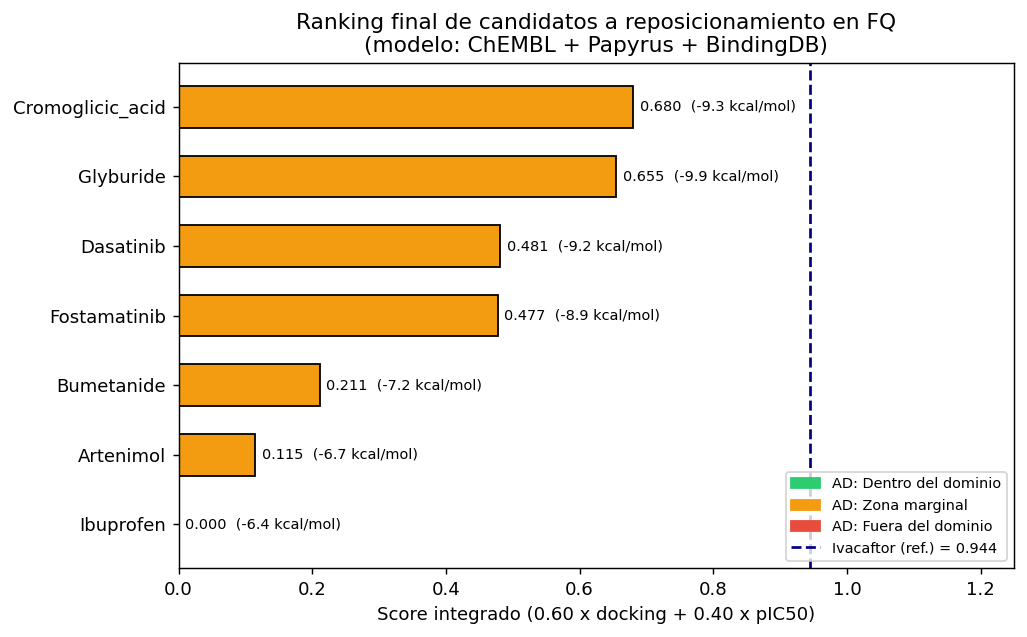

Guardado: fig_ranking_final.png


In [69]:
fig, ax = plt.subplots(figsize=(8, 5))

color_map = {'Alta (dentro del dominio)': '#2ecc71',
             'Media (zona marginal)':     '#f39c12',
             'Baja (fuera del dominio)':  '#e74c3c'}

# Orden inverso para que el #1 quede arriba
nombres = df_rank['nombre'].tolist()[::-1]
scores  = df_rank['score_final'].tolist()[::-1]
docks   = df_rank['dock_media'].tolist()[::-1]
conf    = df_rank['confianza_prediccion'].tolist()[::-1]
colores = [color_map.get(c, 'steelblue') for c in conf]

bars = ax.barh(nombres, scores, color=colores, edgecolor='black', height=0.6)

ax.axvline(ivacaftor['score_final'], color='navy', linestyle='--', linewidth=1.5,
           label=f"Ivacaftor (ref.) = {ivacaftor['score_final']:.3f}")

# Etiqueta: score normalizado + energía real de docking
for bar, s, d in zip(bars, scores, docks):
    ax.text(s + 0.01, bar.get_y() + bar.get_height()/2,
            f'{s:.3f}  ({d:.1f} kcal/mol)', va='center', fontsize=8)

leyenda = [
    mpatches.Patch(color='#2ecc71', label='AD: Dentro del dominio'),
    mpatches.Patch(color='#f39c12', label='AD: Zona marginal'),
    mpatches.Patch(color='#e74c3c', label='AD: Fuera del dominio'),
]
ax.legend(handles=leyenda + [ax.lines[0]], loc='lower right', fontsize=8)
ax.set_xlabel('Score integrado (0.60 x docking + 0.40 x pIC50)')
ax.set_title('Ranking final de candidatos a reposicionamiento en FQ\n'
             '(modelo: ChEMBL + Papyrus + BindingDB)')
ax.set_xlim(0, 1.25)
plt.tight_layout()
plt.savefig('fig_ranking_final.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: fig_ranking_final.png")

### 14.2 Importancia de los descriptores en el modelo

Los 7 primeros valores corresponden a los descriptores fisicoquímicos; el resto
son bits del Morgan fingerprint.

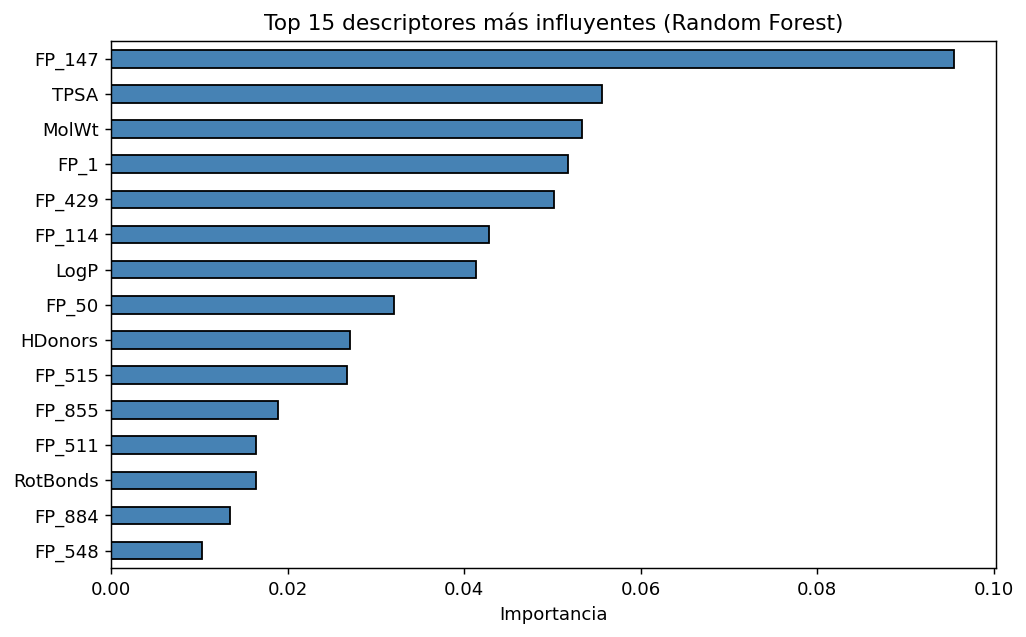

Guardado: fig_importancia_features.png


In [70]:
nombres_desc = ['MolWt', 'LogP', 'TPSA', 'HDonors',
                'HAcceptors', 'RotBonds', 'AromRings']
nombres_feat = nombres_desc + [f'FP_{i}' for i in range(FP_SIZE)]

importancias = pd.Series(rf.feature_importances_, index=nombres_feat)
top15 = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
top15[::-1].plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Importancia')
ax.set_title('Top 15 descriptores más influyentes (Random Forest)')
plt.tight_layout()
plt.savefig('fig_importancia_features.png', dpi=300, bbox_inches='tight')
plt.show()
print("Guardado: fig_importancia_features.png")

---
## 15. Exportar resultados

Guardamos el ranking final y la tabla de validación con controles en CSV para
incorporarlos a la memoria del TFM.

In [71]:
# Ranking de candidatos (+ Ivacaftor como referencia)
cols_export = ['nombre', 'hub_diana', 'drugbank_id', 'indicacion',
               'dock_wt', 'dock_delta', 'dock_media',
               'pIC50_pred', 'tanimoto_max', 'confianza_prediccion',
               'dock_norm', 'pic50_norm', 'score_final']

df_export = pd.concat([
    df_rank[cols_export],
    df_cand[df_cand['nombre'] == 'Ivacaftor'][cols_export]
], ignore_index=True)
df_export.to_csv('ranking_final.csv', index=False)
print("Exportado: ranking_final.csv")
print(df_export.round(3).to_string(index=False))

# Tabla de validación con todos los grupos
cols_val = ['nombre', 'grupo', 'hub_diana', 'pIC50_pred',
            'tanimoto_max', 'confianza_prediccion', 'dock_media']
df_mol[cols_val].round(3).to_csv('validacion_controles.csv', index=False)
print("\nExportado: validacion_controles.csv")

Exportado: ranking_final.csv
          nombre hub_diana drugbank_id      indicacion  dock_wt  dock_delta  dock_media  pIC50_pred  tanimoto_max      confianza_prediccion  dock_norm  pic50_norm  score_final
Cromoglicic_acid  HSP90AA1     DB01003    Antialérgico   -9.347      -9.326      -9.336       6.390         0.233     Media (zona marginal)      0.839       0.441        0.680
       Glyburide      CFTR     DB01016   Antidiabético  -10.105      -9.684      -9.894       5.768         0.333     Media (zona marginal)      1.000       0.136        0.655
       Dasatinib     HSPA8     DB01254  Antineoplásico   -9.131      -9.242      -9.186       5.508         0.272     Media (zona marginal)      0.796       0.009        0.481
    Fostamatinib    PRKACA     DB12010 Inmunomodulador   -9.009      -8.781      -8.895       5.746         0.229     Media (zona marginal)      0.712       0.126        0.477
      Bumetanide      CFTR     DB00887       Diurético   -7.210      -7.147      -7.178    

---

# 16. Figura comparativa de los cuatro perfiles PLIP

Un gráfico de barras agrupadas: eje X = los 4 candidatos, eje Y = número de interacciones, una barra por tipo (H-bonds, hidrofóbicas, π-stacking, salt bridges).


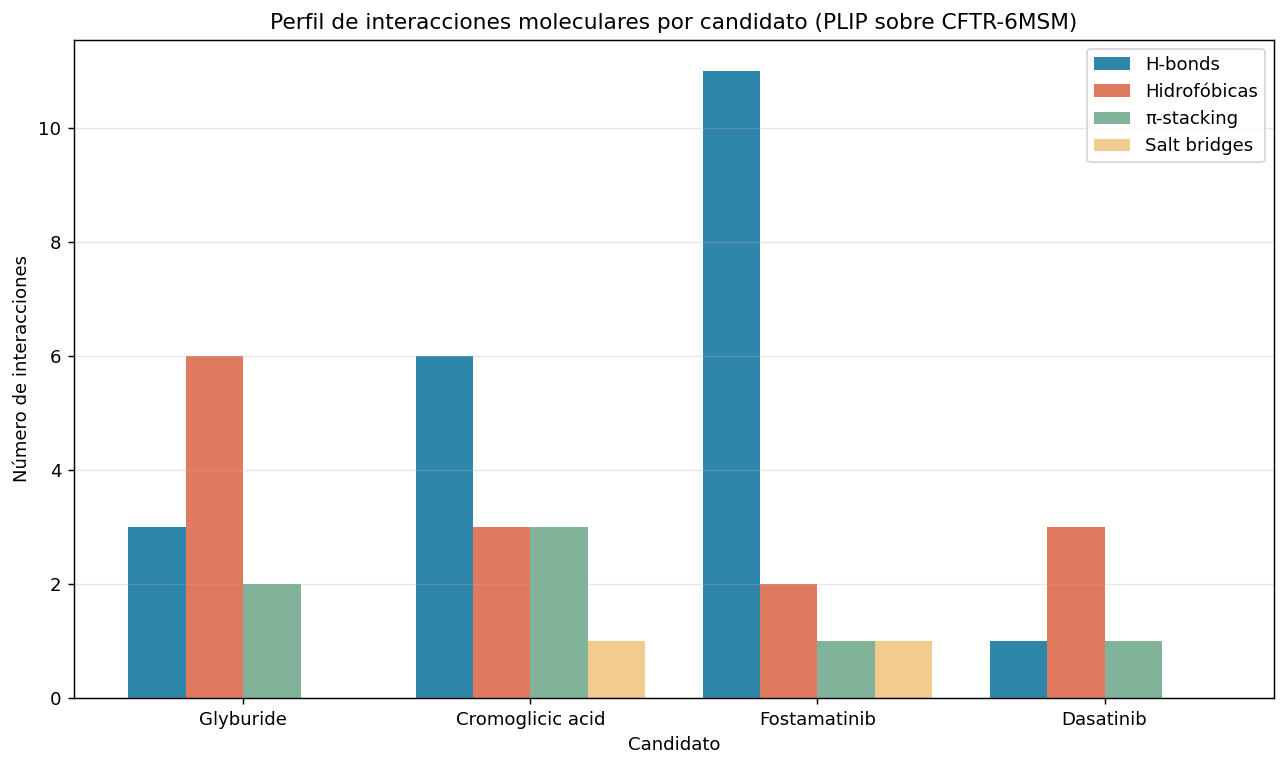

In [72]:
import matplotlib.pyplot as plt
import numpy as np

candidatos = ['Glyburide', 'Cromoglicic acid', 'Fostamatinib', 'Dasatinib']
h_bonds = [3, 6, 11, 1]
hidrofobicas = [6, 3, 2, 3]
pi_stacking = [2, 3, 1, 1]
salt_bridges = [0, 1, 1, 0]

x = np.arange(len(candidatos))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - 1.5*width, h_bonds, width, label='H-bonds', color='#2E86AB')
ax.bar(x - 0.5*width, hidrofobicas, width, label='Hidrofóbicas', color='#E07A5F')
ax.bar(x + 0.5*width, pi_stacking, width, label='π-stacking', color='#81B29A')
ax.bar(x + 1.5*width, salt_bridges, width, label='Salt bridges', color='#F2CC8F')

ax.set_xlabel('Candidato')
ax.set_ylabel('Número de interacciones')
ax.set_title('Perfil de interacciones moleculares por candidato (PLIP sobre CFTR-6MSM)')
ax.set_xticks(x)
ax.set_xticklabels(candidatos)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('figura_plip_comparativa.png', dpi=200, bbox_inches='tight')
plt.show()